# Predikce nájemného - Neuronové sítě

Tento notebook obsahuje implementaci neuronových sítí pro predikci nájemného bytů v ČR:
- **Vícevrstvý perceptron (MLP)** - klasická plně propojená síť
- **Konvoluční neuronová síť (CNN)** - experimentální přístup pro tabulková data

## 1. Import knihoven a načtení dat

In [1]:
import pandas as pd
import numpy as np
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

from tensorflow.keras import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Dropout, Conv2D, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import MeanAbsoluteError
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Nastavení random seed pro reprodukovatelnost
np.random.seed(42)

In [2]:
# Načtení dat
data = pd.read_csv('../data/apartment_properties_rent.csv')
print(f'Počet záznamů: {len(data)}')
data.head()

Počet záznamů: 20659


,id,building_type,city,condition,estate_type,floor_space,land_space,price,region,sale_type,source,disposition,equipment,penb
0,845394,UNDEFINED,Mariánské Lázně,UNDEFINED,apartment,20.0,0.0,16340.0,Karlovarský kraj,RENT,bezrealitky,DISP_1_KK,FURNISHED,G
1,600390,PANEL,Brno,VERY_GOOD,apartment,36.0,0.0,9500.0,Jihomoravský kraj,RENT,bezrealitky,DISP_1_KK,PARTIALLY,A
2,843682,BRICK,Brno,VERY_GOOD,apartment,60.0,0.0,20500.0,Jihomoravský kraj,RENT,bezrealitky,DISP_2_1,FURNISHED,G
3,435994,BRICK,Opava,VERY_GOOD,apartment,38.0,0.0,7000.0,Moravskoslezský kraj,RENT,bezrealitky,DISP_1_1,PARTIALLY,G
4,843695,BRICK,Lipník nad Bečvou,VERY_GOOD,apartment,41.0,0.0,5200.0,Olomoucký kraj,RENT,bezrealitky,DISP_1_1,PARTIALLY,G


## 2. Předzpracování dat

In [3]:
# Zamíchání dat pro lepší generalizaci
data_shuffled = data.sample(n=len(data), random_state=1)

# Vyplnění chybějících hodnot
data_shuffled.loc[:, 'condition'] = data_shuffled['condition'].fillna('UNDEFINED')
data_shuffled.loc[:, 'land_space'] = data_shuffled['land_space'].fillna(0)
data_shuffled.loc[:, 'disposition'] = data_shuffled['disposition'].fillna('UNDEFINED')
data_shuffled.loc[:, 'equipment'] = data_shuffled['equipment'].fillna('UNDEFINED')
data_shuffled.loc[:, 'penb'] = data_shuffled['penb'].fillna('G')

In [4]:
# Odstranění outlierů
print(f'Počet řádků před odstraněním outlierů: {len(data_shuffled)}')

Q99 = data_shuffled['price'].quantile(0.99)

data_shuffled = data_shuffled[
    (data_shuffled['price'] >= 1000) &
    (data_shuffled['price'] <= Q99) &
    (data_shuffled['floor_space'] >= 10) &
    (data_shuffled['floor_space'] <= 250)
].copy()

print(f'Počet řádků po odstranění outlierů: {len(data_shuffled)}')
print(f'\nStatistiky cen:')
print(f'Průměr: {data_shuffled["price"].mean():.2f} Kč')
print(f'Medián: {data_shuffled["price"].median():.2f} Kč')

Počet řádků před odstraněním outlierů: 20659
Počet řádků po odstranění outlierů: 20172

Statistiky cen:
Průměr: 17687.38 Kč
Medián: 14000.00 Kč


In [5]:
# Odstranění nepotřebných sloupců
data_shuffled.drop(['estate_type', 'sale_type', 'source', 'id'], axis=1, inplace=True)

In [6]:
# Target encoding pro vysokokardinální kategorické proměnné
target_cols = ['city', 'region', 'disposition']
target_encoder = ce.TargetEncoder(cols=target_cols)
data_shuffled[target_cols] = target_encoder.fit_transform(data_shuffled[target_cols], data_shuffled['price'])

In [7]:
# Ordinální kódování pro equipment a penb
equipment_mapping = {'UNDEFINED': 0, 'UNFURNISHED': 1, 'PARTIALLY': 2, 'FURNISHED': 3}
penb_mapping = {'G': 0, 'F': 1, 'E': 2, 'D': 3, 'C': 4, 'B': 5, 'A': 6}

data_shuffled['equipment'] = data_shuffled['equipment'].map(equipment_mapping)
data_shuffled['penb'] = data_shuffled['penb'].map(penb_mapping)

In [8]:
# Odstranění zbývajících NaN hodnot
data_shuffled.dropna(inplace=True)
print(f'Finální počet záznamů: {len(data_shuffled)}')

Finální počet záznamů: 20081


In [9]:
# Rozdělení na features a target
X = data_shuffled.drop('price', axis=1)
y = data_shuffled['price']

## 3. Preprocessing pipeline (se StandardScaler)

Pro neuronové sítě je škálování **nutné** - bez něj by model konvergoval pomalu nebo vůbec.

In [10]:
numeric_features = X.select_dtypes(include=[np.number]).columns
categorical_features = ['condition', 'building_type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())  # Nutné pro neuronové sítě
        ]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ]
)

X_preprocessed = preprocessor.fit_transform(X)
print(f'Shape po preprocessingu: {X_preprocessed.shape}')

Shape po preprocessingu: (20081, 32)


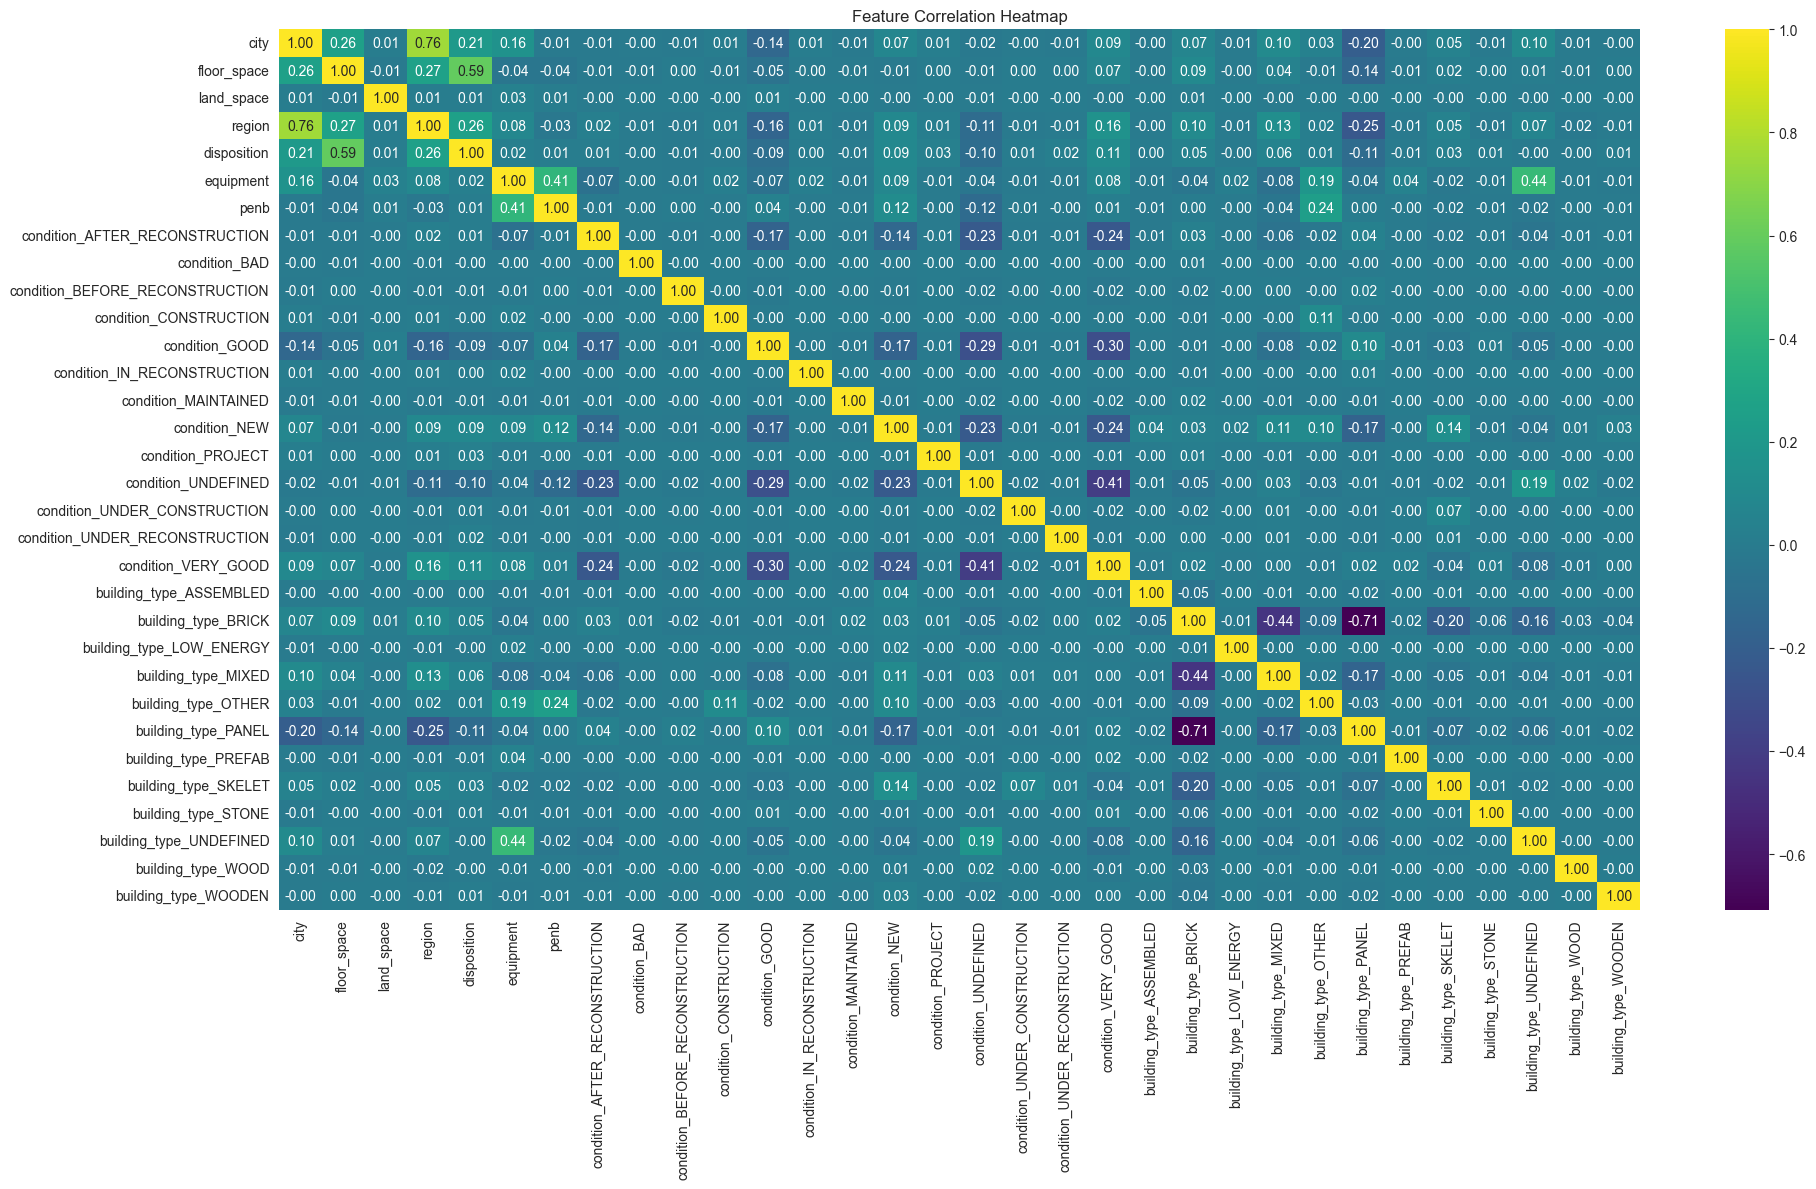

In [11]:
# Korelační matice
categorical_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
all_feature_names = list(numeric_features) + list(categorical_feature_names)

X_preprocessed_df = pd.DataFrame(X_preprocessed, columns=all_feature_names)
correlation_matrix = X_preprocessed_df.corr()

plt.figure(figsize=(20, 12))
sns.heatmap(correlation_matrix, annot=True, cmap="viridis", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 4. Rozdělení dat

In [12]:
# Train/Val/Test split: 60/20/20
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1)

print(f'Train size: {len(X_train)}')
print(f'Validation size: {len(X_val)}')
print(f'Test size: {len(X_test)}')

Train size: 12048
Validation size: 4016
Test size: 4017


## 5. Vícevrstvý perceptron (MLP)

Architektura: 256 → 128 → 64 → 32 → 1
- L2 regularizace proti overfittingu
- Early stopping pro optimální počet epoch
- ReduceLROnPlateau pro adaptivní learning rate

In [13]:
# Dodatečné škálování (už máme ze StandardScaler, ale pro jistotu)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [14]:
# Definice MLP modelu
mlp = Sequential([
    InputLayer(shape=(X_train_scaled.shape[1],)),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(1, activation='linear')
])

mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,713 (202.00 KB)

 Trainable params: 51,713 (202.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Kompilace a trénování
opt = Adam(learning_rate=0.001)
cp = ModelCheckpoint('../models/multilayer_perceptron.keras', save_best_only=True, monitor='val_loss', mode='min')
es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

mlp.compile(optimizer=opt, loss='mae', metrics=[MeanAbsoluteError()])

history_mlp = mlp.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[cp, es, rlr],
    verbose=1
)

Epoch 1/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 841us/step - loss: 12226.8896 - mean_absolute_error: 12226.0850 - val_loss: 3806.2114 - val_mean_absolute_error: 3804.8538 - learning_rate: 0.0010
Epoch 2/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step - loss: 3723.9482 - mean_absolute_error: 3722.5889 - val_loss: 3709.9617 - val_mean_absolute_error: 3708.6094 - learning_rate: 0.0010
Epoch 3/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step - loss: 3658.2019 - mean_absolute_error: 3656.8438 - val_loss: 3683.8645 - val_mean_absolute_error: 3682.4858 - learning_rate: 0.0010
Epoch 4/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 592us/step - loss: 3603.7385 - mean_absolute_error: 3602.3684 - val_loss: 3669.5137 - val_mean_absolute_error: 3668.1375 - learning_rate: 0.0010
Epoch 5/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 674us/step - loss: 3548.0676 - mean_absolute_error: 3546.6777 - val_loss: 3634.8762 - val_mean_absolute_error: 3633.4739 - learning_rate: 0.0010
Epoch 6/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/ste

In [16]:
# Vyhodnocení MLP
y_pred_mlp = mlp.predict(X_test_scaled)
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print(f'=== MLP Výsledky ===')
print(f'MAE: {mae_mlp:.2f} Kč')
print(f'R²: {r2_mlp:.4f}')

126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 444us/step
=== MLP Výsledky ===
MAE: 3302.96 Kč
R²: 0.8096


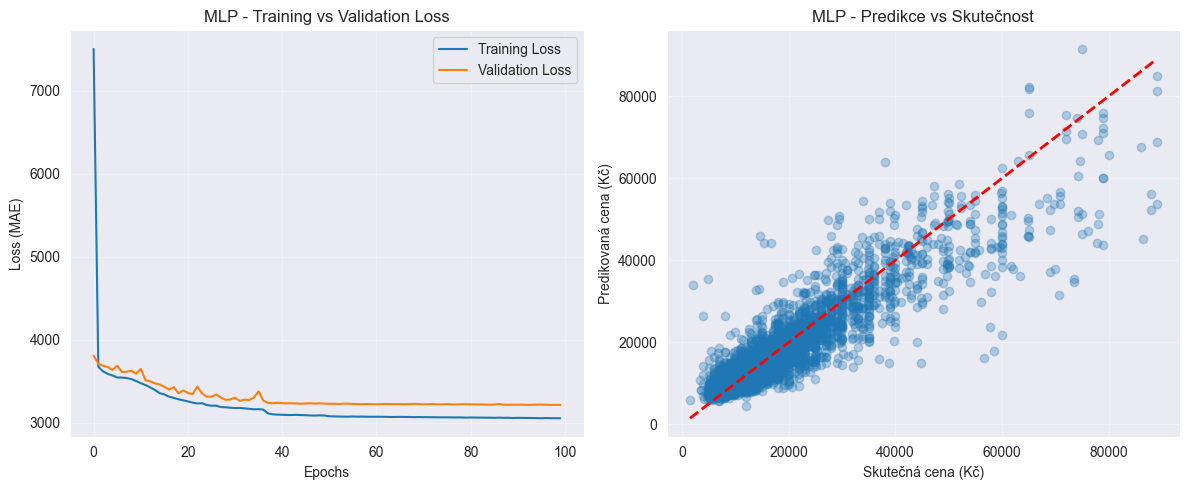

In [17]:
# Vizualizace trénování MLP
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_mlp.history['loss'], label='Training Loss')
plt.plot(history_mlp.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MAE)')
plt.legend()
plt.title('MLP - Training vs Validation Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_mlp, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Skutečná cena (Kč)')
plt.ylabel('Predikovaná cena (Kč)')
plt.title('MLP - Predikce vs Skutečnost')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Konvoluční neuronová síť (CNN)

Experimentální přístup - CNN typicky funguje lépe pro obrazová data, ale můžeme zkusit aplikovat na tabulková data.
Features jsou přetvořeny do 2D formátu pro Conv2D vrstvy.

In [18]:
# Přetvoření dat pro CNN
num_features = X_preprocessed.shape[1]
X_train_cnn = X_train_scaled.reshape(-1, num_features, 1, 1)
X_val_cnn = X_val_scaled.reshape(-1, num_features, 1, 1)
X_test_cnn = X_test_scaled.reshape(-1, num_features, 1, 1)

print(f'CNN input shape: {X_train_cnn.shape}')

CNN input shape: (12048, 32, 1, 1)


In [19]:
# Definice CNN modelu
cnn = Sequential([
    InputLayer(shape=(num_features, 1, 1)),
    Conv2D(filters=16, kernel_size=(3, 1), activation='relu', padding='same'),
    Conv2D(filters=32, kernel_size=(3, 1), activation='relu', padding='same'),
    Flatten(),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(1, activation='linear')
])

cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 1, 16)      │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 1, 32)      │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,345 (270.88 KB)

 Trainable params: 69,345 (270.88 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Kompilace a trénování CNN
opt = Adam(learning_rate=0.0005)
cp = ModelCheckpoint('../models/convolutional_neural_network.keras', save_best_only=True, monitor='val_loss', mode='min')
es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

cnn.compile(optimizer=opt, loss='mae', metrics=['mae'])

history_cnn = cnn.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[cp, es, rlr],
    verbose=1
)

Epoch 1/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 15313.0361 - mae: 15312.6357 - val_loss: 6956.3628 - val_mae: 6955.2061 - learning_rate: 5.0000e-04
Epoch 2/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6303.7100 - mae: 6302.4526 - val_loss: 4416.6294 - val_mae: 4415.0347 - learning_rate: 5.0000e-04
Epoch 3/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4297.0474 - mae: 4295.4165 - val_loss: 4110.6504 - val_mae: 4108.9756 - learning_rate: 5.0000e-04
Epoch 4/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4099.4185 - mae: 4097.7344 - val_loss: 4038.8906 - val_mae: 4037.1975 - learning_rate: 5.0000e-04
Epoch 5/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3934.7078 - mae: 3932.9973 - val_loss: 3948.4954 - val_mae: 3946.7783 - learning_rate: 5.0000e-04
Epoch 6/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3935.1692 - mae: 3933.4460 - val_loss: 3937.6418 - val_mae: 3935.9075 - learning_rate: 5.0000e-04
Epoch 7/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [21]:
# Vyhodnocení CNN
y_pred_cnn = cnn.predict(X_test_cnn)
mae_cnn = mean_absolute_error(y_test, y_pred_cnn)
r2_cnn = r2_score(y_test, y_pred_cnn)

print(f'=== CNN Výsledky ===')
print(f'MAE: {mae_cnn:.2f} Kč')
print(f'R²: {r2_cnn:.4f}')

126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step
=== CNN Výsledky ===
MAE: 3472.58 Kč
R²: 0.7972


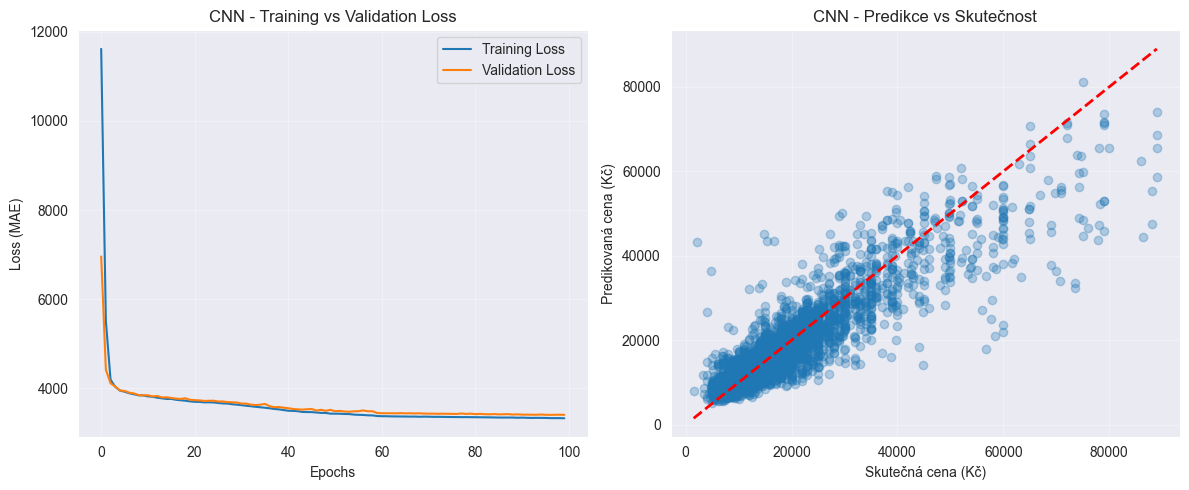

In [22]:
# Vizualizace trénování CNN
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MAE)')
plt.legend()
plt.title('CNN - Training vs Validation Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_cnn, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Skutečná cena (Kč)')
plt.ylabel('Predikovaná cena (Kč)')
plt.title('CNN - Predikce vs Skutečnost')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Porovnání modelů

In [23]:
# Shrnutí výsledků
results = pd.DataFrame({
    'Model': ['MLP', 'CNN'],
    'MAE (Kč)': [mae_mlp, mae_cnn],
    'R²': [r2_mlp, r2_cnn]
})

print('=== POROVNÁNÍ NEURONOVÝCH SÍTÍ ===')
print(results.to_string(index=False))
print(f'\nLepší model: {"MLP" if mae_mlp < mae_cnn else "CNN"}')

=== POROVNÁNÍ NEURONOVÝCH SÍTÍ ===
Model    MAE (Kč)       R²
  MLP 3302.958596 0.809553
  CNN 3472.576348 0.797248

Lepší model: MLP


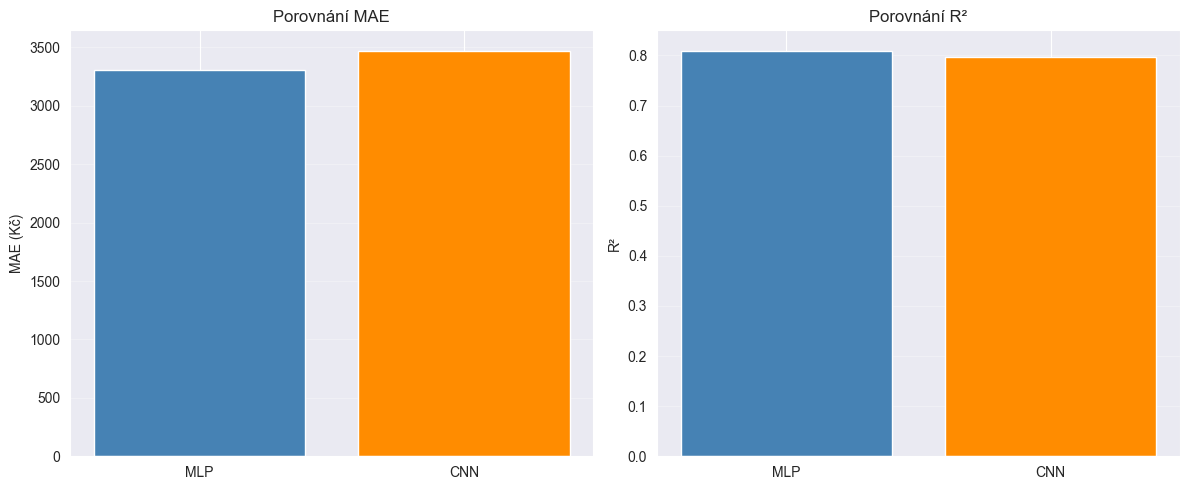

In [24]:
# Vizuální porovnání
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = ['MLP', 'CNN']
maes = [mae_mlp, mae_cnn]
r2s = [r2_mlp, r2_cnn]

axes[0].bar(models, maes, color=['steelblue', 'darkorange'])
axes[0].set_ylabel('MAE (Kč)')
axes[0].set_title('Porovnání MAE')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(models, r2s, color=['steelblue', 'darkorange'])
axes[1].set_ylabel('R²')
axes[1].set_title('Porovnání R²')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Závěr

**Poznámky:**
- MLP typicky funguje lépe než CNN pro tabulková data
- CNN je navržena pro prostorová data (obrázky), kde sousední pixely spolu souvisí
- Pro tabulková data features nemají prostorový vztah, takže konvoluce nemá velký přínos
- Pro lepší výsledky na tabulkových datech doporučujeme použít XGBoost (viz `xgboost_model.ipynb`)